In [ ]:
%pip install pandas

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 16.9 MB/s eta 0:00:01
   ----------- ---------------------------- 3.1/11.3 MB 7.4 MB/s eta 0:00:02
   ---------------- ----------------------- 4.7/11.3 MB 7.3 MB/s eta 0:00:01
   ------------------- -------------------- 5.5/11.3 MB 6.6 MB/s eta 0:00:01
   ---------------------- ----------------- 6.3/11.3 MB 5.9 MB/s eta 0:00:01
   ----------------------- ---------------- 6.6/11.3 MB 5.4 MB/s eta 0:00:01
   ------------------------ --------------- 7.1/11.3 MB 5.0 MB/s eta 0:00:01
   -------------------------- ------------- 7.6/11.3 MB 4.7 MB/s eta 0:00:01
   ---------------------------- ----------- 8.1/11.3 MB 4.3 MB/s eta 0:00:01
   ------------------------------ --------- 8.7/11.3 MB 4.2 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.3 MB 4.2 MB/s eta 0:00:01
   ------------------------------------ --- 10.2/11.3 MB 4.1 MB/s eta 0:00:01
   -

In [8]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 6.7 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.1 MB 5.8 MB/s eta 0:00:01
   -------------- ------------------------- 2.9/8.1 MB 5.1 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 4.3 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 3.9 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.1 MB 3.5 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 3.4 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.1 MB 3.2 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 3.1 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 3.2 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 3.3 MB/s eta 0:00:01
   ----------------------------

In [2]:
import pandas as pd
import os

panel_file = 'integrated_call_samples_v3.20130502.ALL.panel'

if not os.path.exists(panel_file):
    print("Error: Panel file not found. Check your working directory.")
else:
    # 1. Read data using the actual headers
    df = pd.read_csv(panel_file, sep='\t', usecols=['sample', 'pop', 'super_pop', 'gender'])

    # 2. Filter EAS and EUR
    target_df = df[df['super_pop'].isin(['EAS', 'EUR'])].copy()

    # 3. Map EUR to 1 (Control) and EAS to 2 (Case)
    pheno_map = {'EUR': 1, 'EAS': 2}
    target_df['phenotype'] = target_df['super_pop'].map(pheno_map)

    # 4. Format for PLINK using the exact column name 'sample'
    plink_pheno = pd.DataFrame({
        'FID': target_df['sample'],
        'IID': target_df['sample'],
        'Pheno': target_df['phenotype']
    })

    # 5. Save the output
    output_file = 'eas_eur_phenotype.txt'
    plink_pheno.to_csv(output_file, sep=' ', index=False, header=False)

    print(f"Success! Created {output_file}")
    print(f"Total samples: {len(plink_pheno)}")

Success! Created eas_eur_phenotype.txt
Total samples: 1007


C:\Users\14247\AppData\Local\Temp\ipykernel_29028\2882579259.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(results_file, delim_whitespace=True)


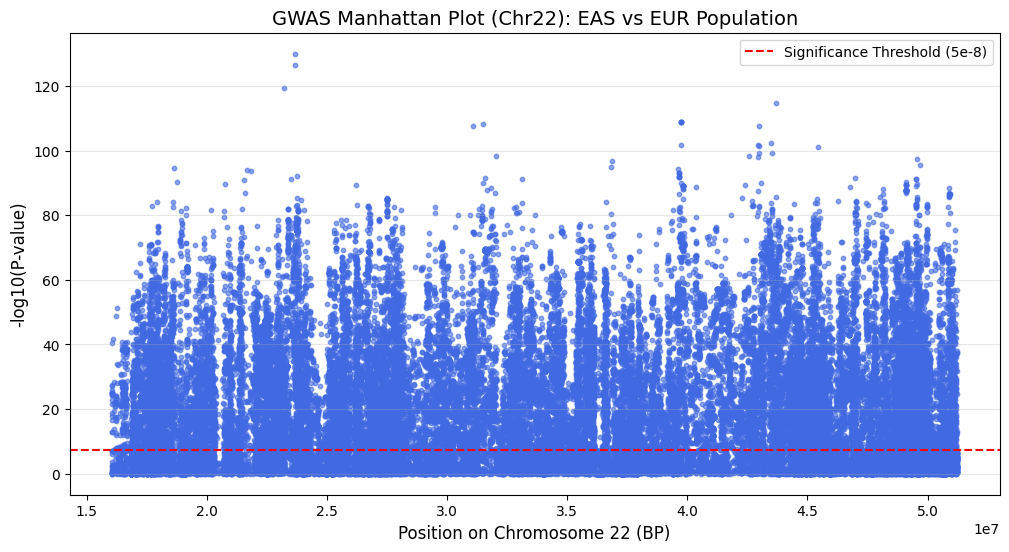

✅ Manhattan plot saved as 'manhattan_chr22.png'


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the results we just generated
results_file = 'chr22_results.assoc'
df = pd.read_csv(results_file, delim_whitespace=True)

# 2. Basic cleanup: Remove rows with missing P-values
df = df.dropna(subset=['P'])

# 3. Calculate -log10(P) for the Y-axis
# This makes tiny P-values (like 1e-20) look like tall buildings (20)
df['minus_log10_p'] = -np.log10(df['P'])

# 4. Plotting
plt.figure(figsize=(12, 6))

# Scatter plot: BP (Position) on X, -log10(P) on Y
plt.scatter(df['BP'], df['minus_log10_p'], c='royalblue', s=10, alpha=0.6)

# Add a "Genome-wide Significance" line (Red dashed line at 5e-8)
# -log10(5e-8) is roughly 7.3
plt.axhline(y=7.3, color='red', linestyle='--', label='Significance Threshold (5e-8)')

# Labels and Title
plt.xlabel('Position on Chromosome 22 (BP)', fontsize=12)
plt.ylabel('-log10(P-value)', fontsize=12)
plt.title('GWAS Manhattan Plot (Chr22): EAS vs EUR Population', fontsize=14)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Save the plot
plt.savefig('manhattan_chr22.png', dpi=300)
plt.show()

print("✅ Manhattan plot saved as 'manhattan_chr22.png'")